In [1]:
%pip install seaborn matplotlib pandas numpy scikit-learn kagglehub

Note: you may need to restart the kernel to use updated packages.


# MalMem-2024 Dataset — Exploratory Data Analysis

## Description
The **MalMem-2024** dataset contains memory dump features extracted using Volatility memory forensics tools, spanning samples from 2006–2021. It is split into two CSV files — one for benign samples and one for malware samples — which are combined here. The dataset consists of **~58,168 samples** and **57 Volatility features** plus metadata columns (`Year`, `Month`).

## Features

| Group | Feature | Description |
|-------|---------|-------------|
| **Target** | `Category` | Malware category (e.g., Benign, Spyware-Transponder-hash, Ransomware-Maze-hash, Trojan-Zeus-hash) |
| | `Class` | Binary label — Benign or Malware |
| **Metadata** | `Year` | Year the sample was collected |
| | `Month` | Month the sample was collected |
| **pslist** | `pslist.nproc` | Number of processes |
| | `pslist.nppid` | Number of parent process IDs |
| | `pslist.avg_threads` | Average number of threads per process |
| | `pslist.nprocs64bit` | Number of 64-bit processes |
| | `pslist.avg_handlers` | Average number of handlers per process |
| **dlllist** | `dlllist.ndlls` | Total number of loaded DLLs |
| | `dlllist.avg_dlls_per_proc` | Average DLLs per process |
| **handles** | `handles.nhandles` | Total number of handles |
| | `handles.avg_handles_per_proc` | Average handles per process |
| | `handles.nport` – `handles.nmutant` | Handle counts by object type |
| **ldrmodules** | `ldrmodules.not_in_load/init/mem` | Counts of modules not in loader lists |
| | `ldrmodules.*_avg` | Average versions of the above |
| **malfind** | `malfind.ninjections` | Number of injected code segments |
| | `malfind.commitCharge` | Committed memory in injected regions |
| | `malfind.protection` | Memory protection flags |
| | `malfind.uniqueInjections` | Unique injection signatures |
| **psxview** | `psxview.not_in_*` | Cross-view detection: processes hidden from various lists |
| | `psxview.*_false_avg` | Average false rates for each view |
| **modules** | `modules.nmodules` | Number of kernel modules |
| **svcscan** | `svcscan.nservices` | Total Windows services |
| | `svcscan.kernel_drivers` – `svcscan.nactive` | Service breakdown by type |
| **callbacks** | `callbacks.ncallbacks` | Total kernel callbacks |
| | `callbacks.nanonymous` | Anonymous (suspicious) callbacks |
| | `callbacks.ngeneric` | Generic callbacks |

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")

# Load both CSVs and combine into a single DataFrame
df_benign = pd.read_csv("../data/raw/All Benign Samples-combined.csv")
df_malware = pd.read_csv("../data/raw/All Malware Samples-Combined2006-2021.csv")

df = pd.concat([df_benign, df_malware], ignore_index=True)

# Strip whitespace from column names (the CSV has "Year " with trailing space)
df.columns = df.columns.str.strip()

print(f"Benign samples: {len(df_benign)}")
print(f"Malware samples: {len(df_malware)}")
print(f"Combined: {len(df)}")
df.head()

Benign samples: 29298
Malware samples: 28870
Combined: 58168


,Category,Year,Month,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,...,svcscan.kernel_drivers,svcscan.fs_drivers,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,Class
0,Benign,NaN,NaN,45,17,10.555556,0,202.844444,1694,38.500000,...,221,26,24,116,0,121,87,0,8,Benign
1,Benign,NaN,NaN,47,19,11.531915,0,242.234043,2074,44.127660,...,222,26,24,118,0,122,87,0,8,Benign
2,Benign,NaN,NaN,40,14,14.725000,0,288.225000,1932,48.300000,...,222,26,27,118,0,120,88,0,8,Benign
3,Benign,NaN,NaN,32,13,13.500000,0,264.281250,1445,45.156250,...,222,26,27,118,0,120,88,0,8,Benign
4,Benign,NaN,NaN,42,16,11.452381,0,281.333333,2067,49.214286,...,222,26,24,118,0,124,87,0,8,Benign


In [3]:
print(f"Number of rows: {df.shape[0]}, Number of columns: {df.shape[1]}")
print(f"Column names: {df.columns.tolist()}")
print(f"any null values: {df.isnull().sum().any()}")

Number of rows: 58168, Number of columns: 59
Column names: ['Category', 'Year', 'Month', 'pslist.nproc', 'pslist.nppid', 'pslist.avg_threads', 'pslist.nprocs64bit', 'pslist.avg_handlers', 'dlllist.ndlls', 'dlllist.avg_dlls_per_proc', 'handles.nhandles', 'handles.avg_handles_per_proc', 'handles.nport', 'handles.nfile', 'handles.nevent', 'handles.ndesktop', 'handles.nkey', 'handles.nthread', 'handles.ndirectory', 'handles.nsemaphore', 'handles.ntimer', 'handles.nsection', 'handles.nmutant', 'ldrmodules.not_in_load', 'ldrmodules.not_in_init', 'ldrmodules.not_in_mem', 'ldrmodules.not_in_load_avg', 'ldrmodules.not_in_init_avg', 'ldrmodules.not_in_mem_avg', 'malfind.ninjections', 'malfind.commitCharge', 'malfind.protection', 'malfind.uniqueInjections', 'psxview.not_in_pslist', 'psxview.not_in_eprocess_pool', 'psxview.not_in_ethread_pool', 'psxview.not_in_pspcid_list', 'psxview.not_in_csrss_handles', 'psxview.not_in_session', 'psxview.not_in_deskthrd', 'psxview.not_in_pslist_false_avg', 'psxv

In [4]:
# printing data types for each column
for dtype in df.dtypes.unique():
    cols = df.select_dtypes(include=[dtype]).columns.tolist()
    print(f"\n{dtype} ({len(cols)} columns):")
    print(f"  {cols}")


str (2 columns):
  ['Category', 'Class']

float64 (16 columns):
  ['Year', 'pslist.avg_threads', 'pslist.avg_handlers', 'dlllist.avg_dlls_per_proc', 'handles.avg_handles_per_proc', 'ldrmodules.not_in_load_avg', 'ldrmodules.not_in_init_avg', 'ldrmodules.not_in_mem_avg', 'malfind.uniqueInjections', 'psxview.not_in_pslist_false_avg', 'psxview.not_in_eprocess_pool_false_avg', 'psxview.not_in_ethread_pool_false_avg', 'psxview.not_in_pspcid_list_false_avg', 'psxview.not_in_csrss_handles_false_avg', 'psxview.not_in_session_false_avg', 'psxview.not_in_deskthrd_false_avg']

object (3 columns):
  ['Category', 'Month', 'Class']

int64 (40 columns):
  ['pslist.nproc', 'pslist.nppid', 'pslist.nprocs64bit', 'dlllist.ndlls', 'handles.nhandles', 'handles.nport', 'handles.nfile', 'handles.nevent', 'handles.ndesktop', 'handles.nkey', 'handles.nthread', 'handles.ndirectory', 'handles.nsemaphore', 'handles.ntimer', 'handles.nsection', 'handles.nmutant', 'ldrmodules.not_in_load', 'ldrmodules.not_in_init',

/tmp/ipykernel_29644/2176447962.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols = df.select_dtypes(include=[dtype]).columns.tolist()


In [5]:
print(f"Value counts in Class column:\n{df['Class'].value_counts()}\n")
print(f"null values in Class column: {df['Class'].isnull().sum()}\n")

Value counts in Class column:
Class
Benign     29298
Malware    28870
Name: count, dtype: int64

null values in Class column: 0



In [6]:
df['Category'].value_counts()

Category
Benign                                                                                      29298
Ransomware-Maze-074bd82769f9ae3d19df651868d5df03bd86376e0e070d34ff1f5eb686d2e31b-1.raw          2
Ransomware-Maze-074bd82769f9ae3d19df651868d5df03bd86376e0e070d34ff1f5eb686d2e31b-10.raw         2
Ransomware-Maze-074bd82769f9ae3d19df651868d5df03bd86376e0e070d34ff1f5eb686d2e31b-2.raw          2
Ransomware-Maze-074bd82769f9ae3d19df651868d5df03bd86376e0e070d34ff1f5eb686d2e31b-3.raw          2
                                                                                            ...  
Ransomware-Shade-fa03be3078d1b9840f06745f160eb3660824fc6323b3adf76cb5b78d157f0944-8.raw         1
Ransomware-Shade-f56687137caf9a67678cde91e46143a458cd7316f0e6c991789b1136ad624973-8.raw         1
Ransomware-Shade-faddeea111a25da4d0888f3044ae9555f0c55517f6226b30e521008fceda6bbf-7.raw         1
Ransomware-Shade-f866c086af2e1d8ebaa6f2c8631578896768285120b57ddd43453bdebb217ab1-10.raw        1
Ransomware-

In [7]:
# Extract malware category from Category column
# Benign samples have Category="Benign", malware have "Type-Family-hash" format
df["category"] = df["Category"].apply(lambda x: x.split("-")[0])

print(f"Categories:\n{df['category'].value_counts()}")

Categories:
category
Benign        29298
Spyware       10020
Ransomware     9791
Trojan         9059
Name: count, dtype: int64


In [8]:
df["category"].value_counts()

category
Benign        29298
Spyware       10020
Ransomware     9791
Trojan         9059
Name: count, dtype: int64

## Step 1: Drop Metadata Columns
- `Category` contains per-sample file hashes — a unique ID the model could memorize (data leakage).
- `Year` and `Month` are collection metadata, not memory forensic features — including them would let the model learn temporal artifacts instead of malware behavior.

We keep `category` as our **multi-class target** and `Class` as our **binary target**, then drop the rest.

In [9]:
# Save Year before dropping (needed for temporal split later)
sample_year = df["Year"].copy()

df.drop(columns=["Category", "Year", "Month"], inplace=True)
print(f"Columns after drop: {df.shape[1]}")
print(f"Remaining columns: {df.columns.tolist()}")

Columns after drop: 57
Remaining columns: ['pslist.nproc', 'pslist.nppid', 'pslist.avg_threads', 'pslist.nprocs64bit', 'pslist.avg_handlers', 'dlllist.ndlls', 'dlllist.avg_dlls_per_proc', 'handles.nhandles', 'handles.avg_handles_per_proc', 'handles.nport', 'handles.nfile', 'handles.nevent', 'handles.ndesktop', 'handles.nkey', 'handles.nthread', 'handles.ndirectory', 'handles.nsemaphore', 'handles.ntimer', 'handles.nsection', 'handles.nmutant', 'ldrmodules.not_in_load', 'ldrmodules.not_in_init', 'ldrmodules.not_in_mem', 'ldrmodules.not_in_load_avg', 'ldrmodules.not_in_init_avg', 'ldrmodules.not_in_mem_avg', 'malfind.ninjections', 'malfind.commitCharge', 'malfind.protection', 'malfind.uniqueInjections', 'psxview.not_in_pslist', 'psxview.not_in_eprocess_pool', 'psxview.not_in_ethread_pool', 'psxview.not_in_pspcid_list', 'psxview.not_in_csrss_handles', 'psxview.not_in_session', 'psxview.not_in_deskthrd', 'psxview.not_in_pslist_false_avg', 'psxview.not_in_eprocess_pool_false_avg', 'psxview.

## Step 2: Train-Test Splits

Two splitting strategies for comparison:
1. **Random stratified split** — standard 80/20, preserves class ratios
2. **Temporal split** — train on pre-2020 malware, test on 2020–2021 malware. Benign samples (no year) are split randomly 80/20. This tests the model's ability to generalize to future attacks.

In [10]:
from sklearn.model_selection import train_test_split

feature_cols = [c for c in df.columns if c not in ["category", "Class"]]
X = df[feature_cols]
y = df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")
print(f"\nTrain class distribution:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest class distribution:\n{y_test.value_counts(normalize=True).round(3)}")

Train: 46534 samples, Test: 11634 samples

Train class distribution:
category
Benign        0.504
Spyware       0.172
Ransomware    0.168
Trojan        0.156
Name: proportion, dtype: float64

Test class distribution:
category
Benign        0.504
Spyware       0.172
Ransomware    0.168
Trojan        0.156
Name: proportion, dtype: float64


### 2b. Temporal Split

In [11]:
# Temporal split: train on pre-2020, test on 2020-2021
# Benign samples (Year=NaN) are split randomly 80/20
feature_cols = [c for c in df.columns if c not in ["category", "Class"]]

is_benign = sample_year.isna()
is_train_malware = sample_year < 2020
is_test_malware = sample_year >= 2020

# Split benign randomly (80/20) with same random_state
from sklearn.model_selection import train_test_split as tts
benign_idx = df.index[is_benign]
benign_train_idx, benign_test_idx = tts(
    benign_idx, test_size=0.2, random_state=42
)

# Combine
temporal_train_idx = df.index[is_train_malware].append(benign_train_idx)
temporal_test_idx = df.index[is_test_malware].append(benign_test_idx)

X_train_temp = df.loc[temporal_train_idx, feature_cols]
X_test_temp = df.loc[temporal_test_idx, feature_cols]
y_train_temp = df.loc[temporal_train_idx, "category"]
y_test_temp = df.loc[temporal_test_idx, "category"]

print(f"Temporal split:")
print(f"  Train: {len(X_train_temp)} samples (pre-2020 malware + 80% benign)")
print(f"  Test:  {len(X_test_temp)} samples (2020-2021 malware + 20% benign)")
print(f"\nTrain class distribution:\n{y_train_temp.value_counts(normalize=True).round(3)}")
print(f"\nTest class distribution:\n{y_test_temp.value_counts(normalize=True).round(3)}")

Temporal split:
  Train: 39964 samples (pre-2020 malware + 80% benign)
  Test:  18204 samples (2020-2021 malware + 20% benign)

Train class distribution:
category
Benign        0.586
Trojan        0.194
Spyware       0.117
Ransomware    0.103
Name: proportion, dtype: float64

Test class distribution:
category
Benign        0.322
Ransomware    0.313
Spyware       0.293
Trojan        0.072
Name: proportion, dtype: float64


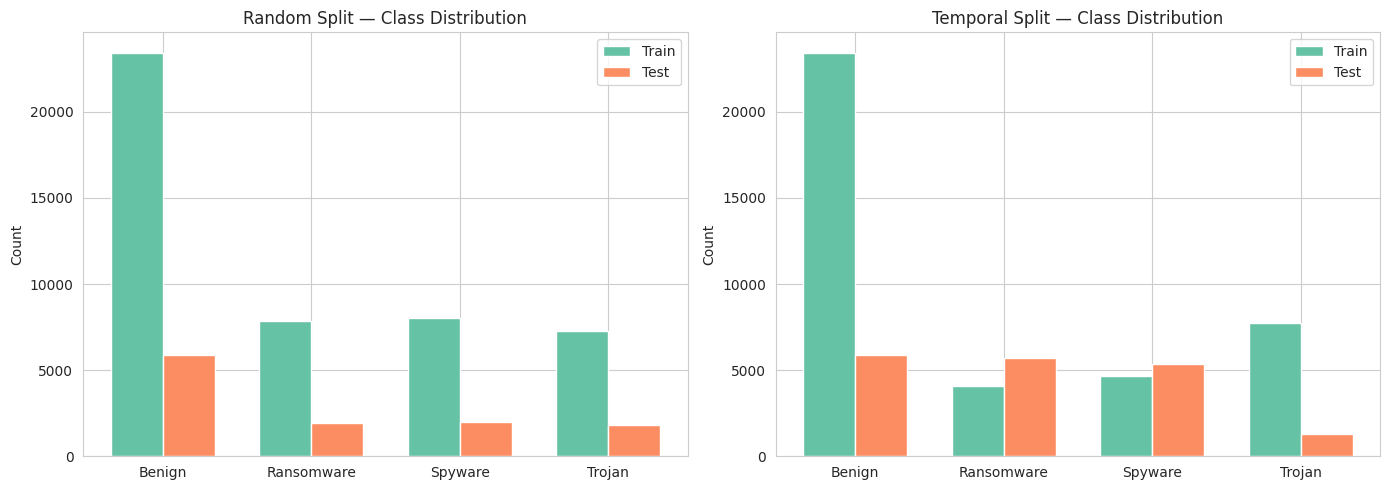

Random split  — Train: 46534, Test: 11634
Temporal split — Train: 39964, Test: 18204


In [12]:
# Compare class distributions: Random vs Temporal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
categories = sorted(y_train.unique())

# Random split
ax = axes[0]
train_counts = y_train.value_counts().reindex(categories)
test_counts = y_test.value_counts().reindex(categories)
x = np.arange(len(categories))
w = 0.35
ax.bar(x - w/2, train_counts, w, label="Train", color="#66c2a5")
ax.bar(x + w/2, test_counts, w, label="Test", color="#fc8d62")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_title("Random Split — Class Distribution")
ax.set_ylabel("Count")
ax.legend()

# Temporal split
ax = axes[1]
train_counts_t = y_train_temp.value_counts().reindex(categories)
test_counts_t = y_test_temp.value_counts().reindex(categories)
ax.bar(x - w/2, train_counts_t, w, label="Train", color="#66c2a5")
ax.bar(x + w/2, test_counts_t, w, label="Test", color="#fc8d62")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_title("Temporal Split — Class Distribution")
ax.set_ylabel("Count")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Random split  — Train: {len(y_train)}, Test: {len(y_test)}")
print(f"Temporal split — Train: {len(y_train_temp)}, Test: {len(y_test_temp)}")

## Step 3: Exploratory Data Analysis (Training Data Only)
All EDA is performed on `X_train` / `y_train` to avoid leaking test-set information.

### 3a. Class Distribution

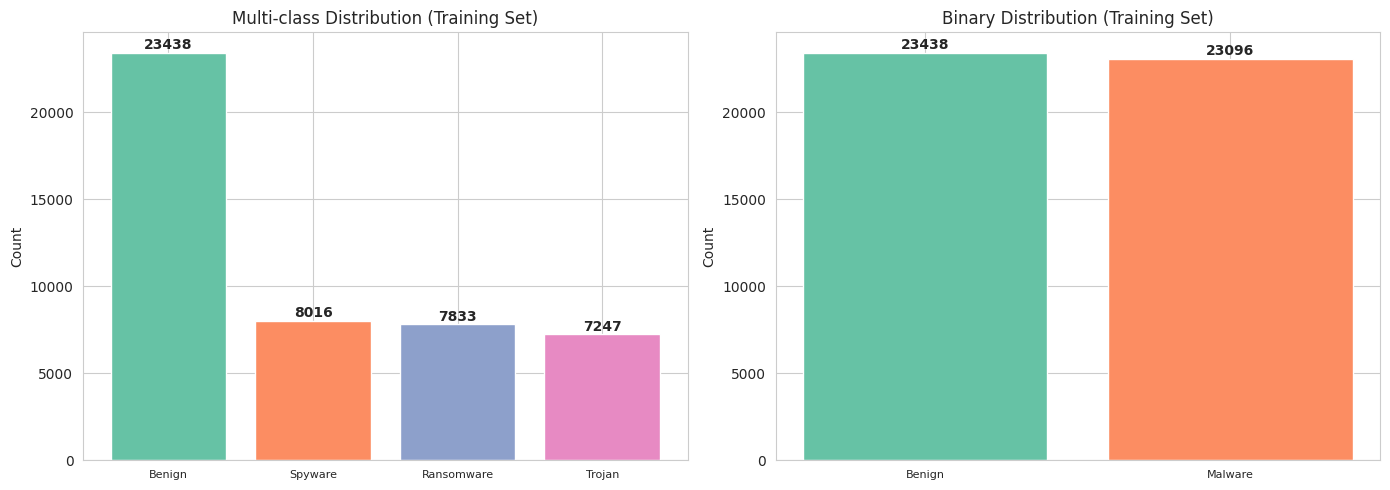

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Multi-class distribution
counts = y_train.value_counts()
axes[0].bar(counts.index, counts.values, color=sns.color_palette("Set2", len(counts)))
axes[0].set_title("Multi-class Distribution (Training Set)")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", labelsize=8)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, str(v), ha="center", fontweight="bold")

# Binary class distribution
binary_counts = df.loc[y_train.index, "Class"].value_counts()
axes[1].bar(binary_counts.index, binary_counts.values, color=["#66c2a5", "#fc8d62"])
axes[1].set_title("Binary Distribution (Training Set)")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", labelsize=8)
for i, v in enumerate(binary_counts.values):
    axes[1].text(i, v + 200, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

### 3b. Correlation Heatmap
Identify highly correlated feature pairs — candidates for removal or further investigation.

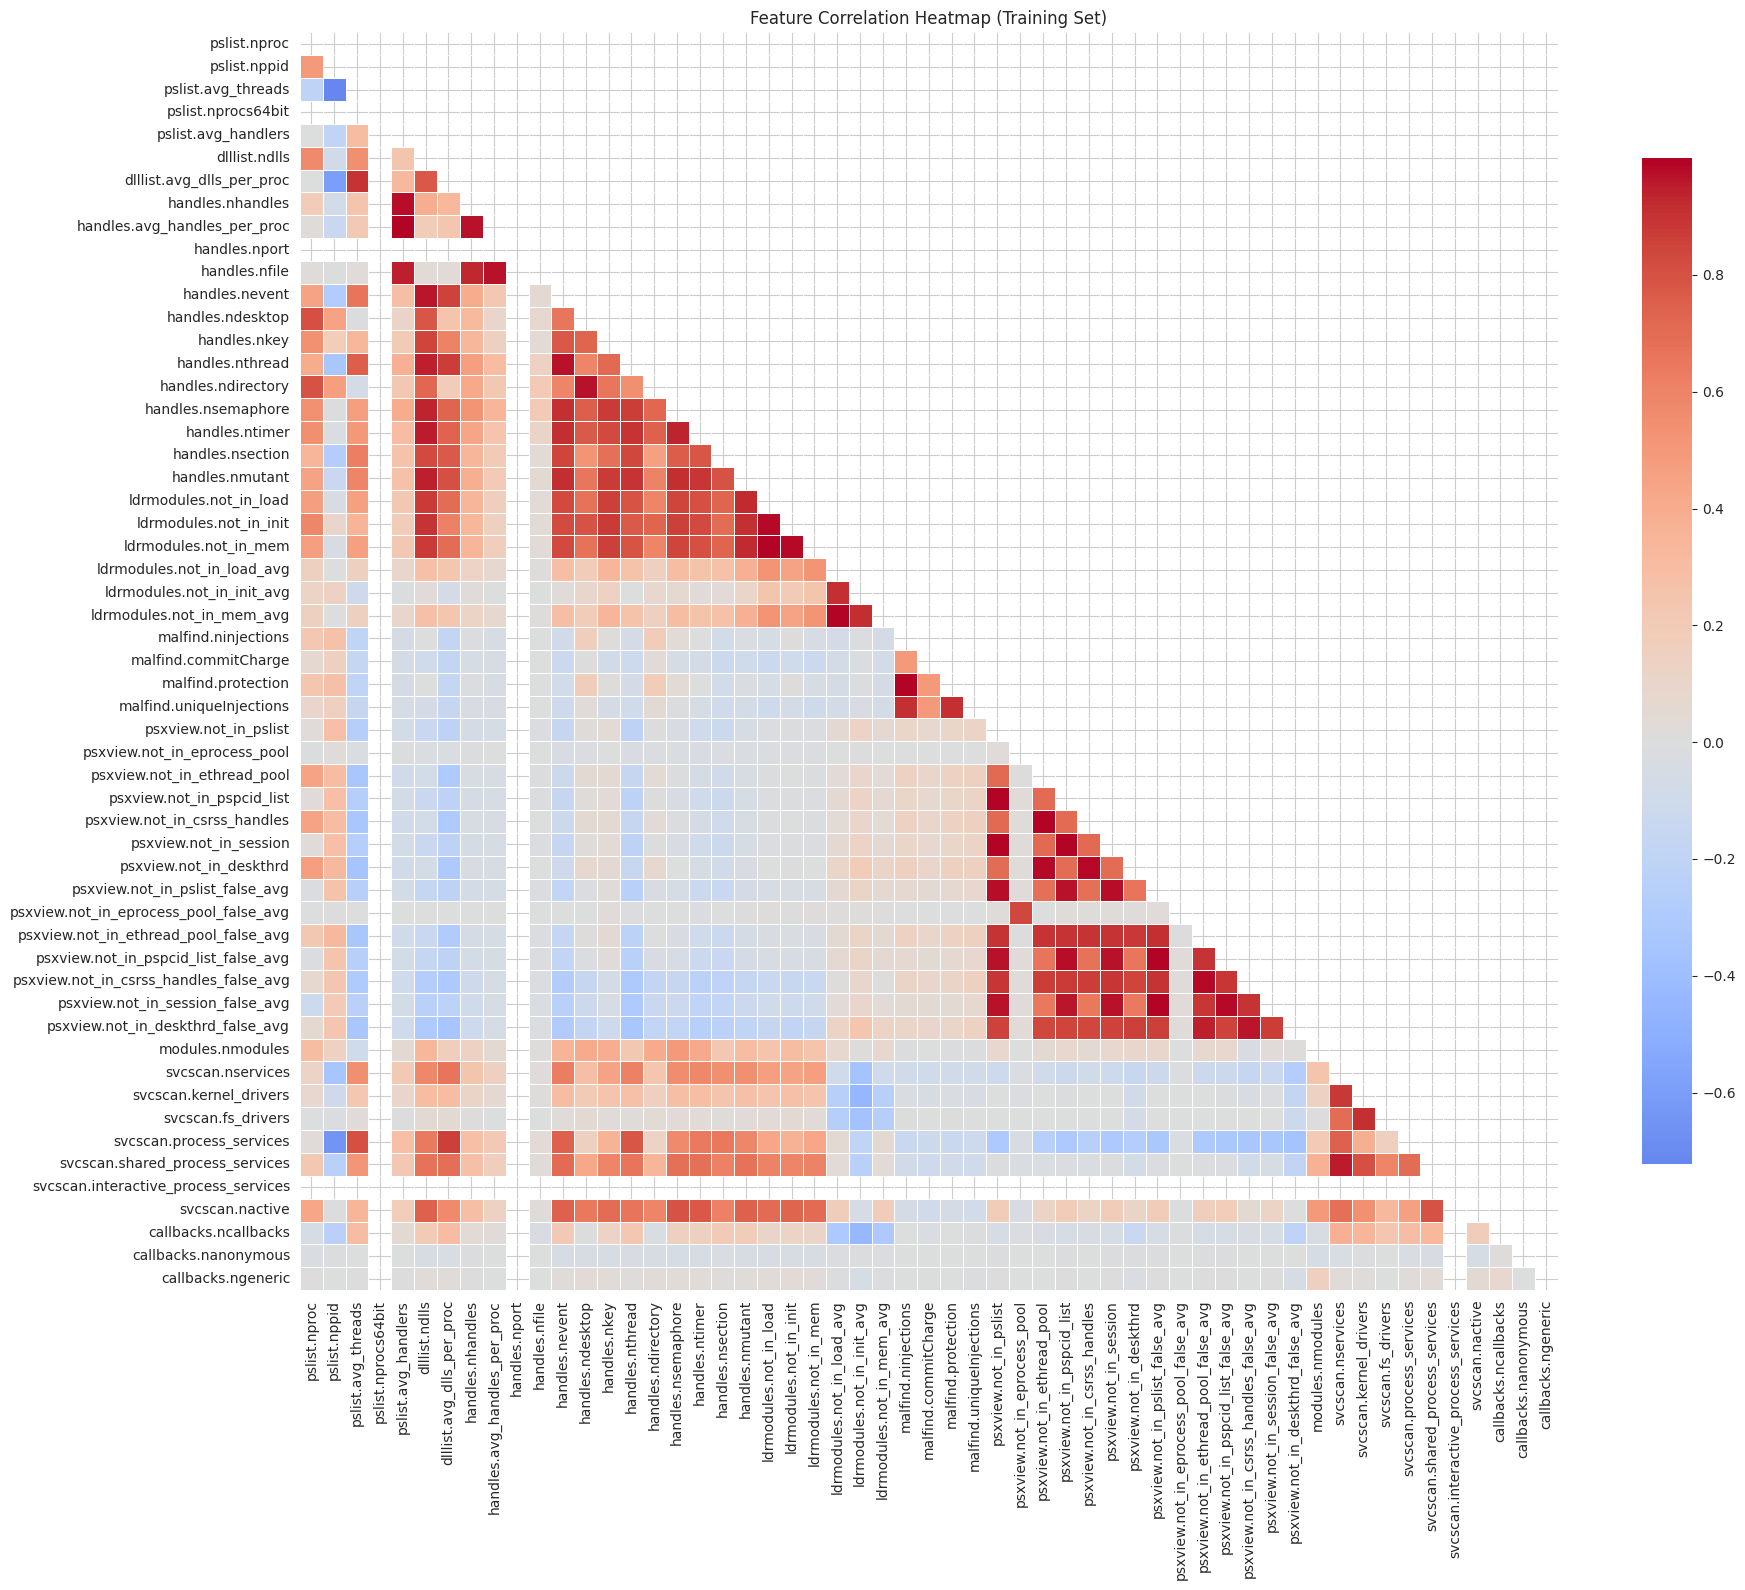


Highly correlated pairs (|r| > 0.9): 58
  ldrmodules.not_in_load <-> ldrmodules.not_in_mem: 1.0
  ldrmodules.not_in_load_avg <-> ldrmodules.not_in_mem_avg: 1.0
  malfind.ninjections <-> malfind.protection: 1.0
  psxview.not_in_pslist <-> psxview.not_in_session: 1.0
  psxview.not_in_ethread_pool <-> psxview.not_in_csrss_handles: 1.0
  pslist.avg_handlers <-> handles.avg_handles_per_proc: 0.994
  psxview.not_in_pslist_false_avg <-> psxview.not_in_session_false_avg: 0.994
  psxview.not_in_pslist <-> psxview.not_in_pspcid_list: 0.992
  psxview.not_in_pspcid_list <-> psxview.not_in_session: 0.992
  psxview.not_in_pslist_false_avg <-> psxview.not_in_pspcid_list_false_avg: 0.987
  psxview.not_in_ethread_pool <-> psxview.not_in_deskthrd: 0.985
  psxview.not_in_csrss_handles <-> psxview.not_in_deskthrd: 0.985
  ldrmodules.not_in_load <-> ldrmodules.not_in_init: 0.981
  ldrmodules.not_in_init <-> ldrmodules.not_in_mem: 0.981
  psxview.not_in_ethread_pool_false_avg <-> psxview.not_in_csrss_handl

In [14]:
import numpy as np
plt.figure(figsize=(20, 16))
corr = X_train.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, linewidths=0.5,
            fmt=".1f", square=True, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Heatmap (Training Set)")
plt.tight_layout()
plt.show()

# Flag highly correlated pairs (|r| > 0.9)
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.9:
            high_corr.append((corr.columns[i], corr.columns[j], round(corr.iloc[i, j], 3)))

print(f"\nHighly correlated pairs (|r| > 0.9): {len(high_corr)}")
for a, b, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {a} <-> {b}: {r}")

### 3c. Feature Distributions
Check for skewness — highly skewed features may benefit from log transforms.

Top 10 most skewed features:
handles.nfile                   199.845948
handles.avg_handles_per_proc    189.731754
pslist.avg_handlers             170.323865
handles.nhandles                157.488655
callbacks.nanonymous             34.952232
psxview.not_in_eprocess_pool     22.182793
ldrmodules.not_in_init_avg       20.872574
handles.nsection                 20.566262
ldrmodules.not_in_load_avg       19.303214
ldrmodules.not_in_mem_avg        19.299732

Bottom 10:
dlllist.avg_dlls_per_proc          -0.027221
handles.ntimer                     -0.070453
svcscan.nactive                    -2.918476
modules.nmodules                   -8.886268
callbacks.ncallbacks               -9.428417
svcscan.shared_process_services   -14.191226
svcscan.nservices                 -21.185729
svcscan.kernel_drivers            -47.249720
svcscan.fs_drivers                -86.809274
callbacks.ngeneric                -96.459318


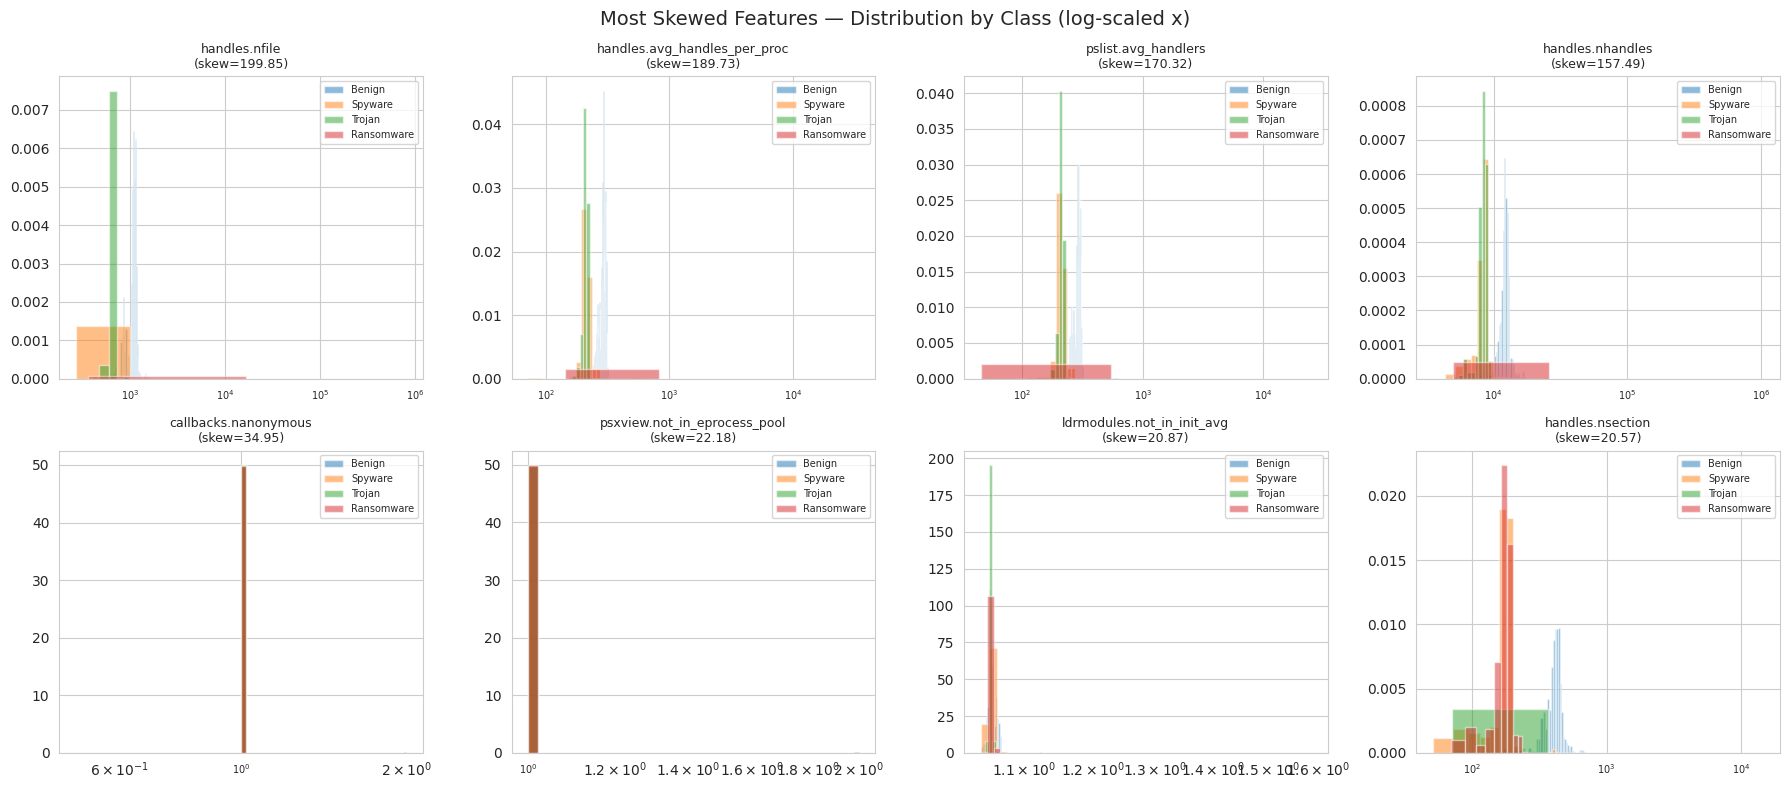

In [15]:
skew = X_train.skew().sort_values(ascending=False)
print("Top 10 most skewed features:")
print(skew.head(10).to_string())
print(f"\nBottom 10:")
print(skew.tail(10).to_string())

# Plot distributions of the 8 most skewed features (log-scaled x-axis)
top_skewed = skew.head(8).index.tolist()
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), top_skewed):
    for cat in y_train.unique():
        subset = X_train.loc[y_train == cat, col]
        # Shift by 1 to handle zeros before log scale
        ax.hist(subset + 1, bins=50, alpha=0.5, label=cat, density=True)
    ax.set_xscale("log")
    ax.set_title(f"{col}\n(skew={skew[col]:.2f})", fontsize=9)
    ax.tick_params(axis="x", labelsize=7)
    ax.legend(fontsize=7)
plt.suptitle("Most Skewed Features — Distribution by Class (log-scaled x)", fontsize=14)
plt.tight_layout()
plt.show()

## Step 4: Missing Values, Duplicates & Outlier Detection

Before any feature engineering, audit data quality:
1. **Missing values** — per-feature null counts and pattern
2. **Duplicate rows** — exact duplicates that could inflate accuracy
3. **Outlier detection** — IQR-based flagging with boxplots (security-aware: extreme values may be real malware signals)

### 4a. Missing Value Audit

No missing values found in any feature.


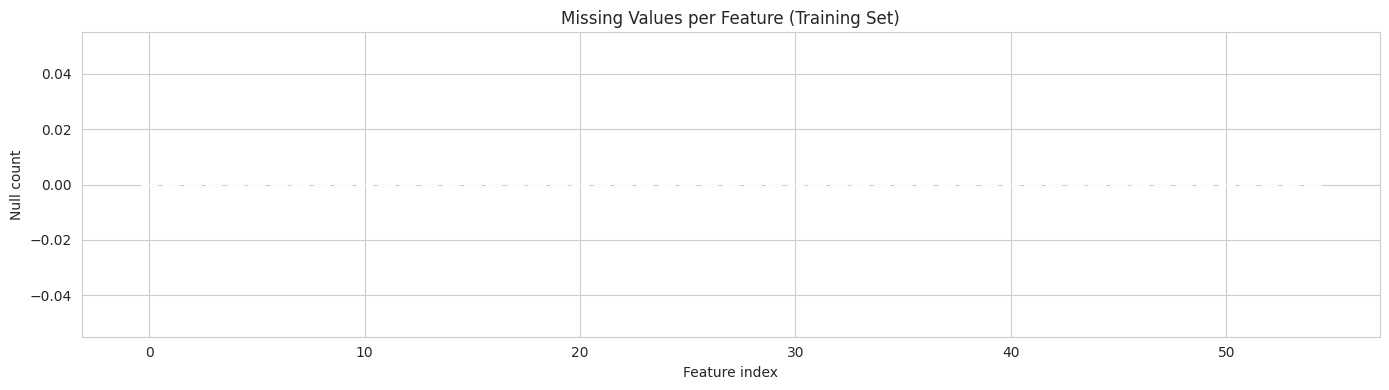


Total nulls: 0 out of 2559370 cells


In [16]:
# Per-feature missing value report
null_counts = X_train.isnull().sum()
null_pct = (null_counts / len(X_train) * 100).round(2)
null_report = pd.DataFrame({"null_count": null_counts, "null_pct": null_pct})
null_report = null_report[null_report["null_count"] > 0].sort_values("null_pct", ascending=False)

if null_report.empty:
    print("No missing values found in any feature.")
else:
    print(f"Features with missing values: {len(null_report)}")
    print(null_report)

# Visualize missing value pattern
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(X_train.shape[1]), X_train.isnull().sum().values, color="coral")
ax.set_xlabel("Feature index")
ax.set_ylabel("Null count")
ax.set_title("Missing Values per Feature (Training Set)")
plt.tight_layout()
plt.show()

print(f"\nTotal nulls: {X_train.isnull().sum().sum()} out of {X_train.shape[0] * X_train.shape[1]} cells")

### 4b. Duplicate Row Check

In [17]:
# Check for exact duplicate rows (features only)
n_dupes = X_train.duplicated().sum()
print(f"Duplicate rows in training set: {n_dupes} ({n_dupes / len(X_train) * 100:.2f}%)")

if n_dupes > 0:
    # Show which classes the duplicates belong to
    dupe_mask = X_train.duplicated(keep=False)
    print(f"\nDuplicate rows by class:")
    print(y_train[dupe_mask].value_counts())
    
    # Drop duplicates (keep first occurrence)
    keep_idx = ~X_train.duplicated(keep="first")
    X_train = X_train[keep_idx]
    y_train = y_train[keep_idx]
    X_test = X_test  # test set unchanged
    print(f"\nAfter dropping duplicates: {X_train.shape[0]} training rows")
else:
    print("No duplicate rows — no action needed.")

Duplicate rows in training set: 371 (0.80%)

Duplicate rows by class:
category
Ransomware    346
Spyware       286
Benign         63
Trojan         10
Name: count, dtype: int64

After dropping duplicates: 46163 training rows


### 4c. Outlier Detection (IQR Method)

Use the Interquartile Range (IQR) method to flag statistical outliers. In memory forensics, extreme values often represent real malware behavior (e.g., massive injection counts), so we **visualize but do not blindly remove** them.

In [18]:
# IQR-based outlier summary
Q1 = X_train.quantile(0.25)
Q3 = X_train.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_counts = ((X_train < lower) | (X_train > upper)).sum()
outlier_pct = (outlier_counts / len(X_train) * 100).round(2)

outlier_report = pd.DataFrame({
    "outlier_count": outlier_counts,
    "outlier_pct": outlier_pct,
    "IQR": IQR.round(3),
    "lower_bound": lower.round(3),
    "upper_bound": upper.round(3),
}).sort_values("outlier_pct", ascending=False)

print("Features with most outliers (IQR method):")
print(outlier_report.head(15).to_string())
print(f"\nTotal features with >5% outliers: {(outlier_pct > 5).sum()}")

Features with most outliers (IQR method):
                                       outlier_count  outlier_pct     IQR  lower_bound  upper_bound
malfind.commitCharge                            5640        12.22   3.000       -1.500       10.500
handles.ndesktop                                5509        11.93   3.000       38.500       50.500
ldrmodules.not_in_init_avg                      5210        11.29   0.004        0.047        0.061
pslist.nproc                                    4969        10.76   3.000       35.500       47.500
malfind.protection                              4643        10.06  12.000        0.000       48.000
malfind.ninjections                             4558         9.87   2.000        0.000        8.000
handles.ndirectory                              3533         7.65   8.000       87.000      119.000
psxview.not_in_deskthrd                         3527         7.64   3.000        1.500       13.500
psxview.not_in_ethread_pool                     3413      

/tmp/ipykernel_29644/4127648472.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=sorted(y_train.unique()), patch_artist=True)
/tmp/ipykernel_29644/4127648472.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=sorted(y_train.unique()), patch_artist=True)
/tmp/ipykernel_29644/4127648472.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=sorted(y_train.unique()), patch_artist=True)
/tmp/ipykernel_29644/4127648472.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib

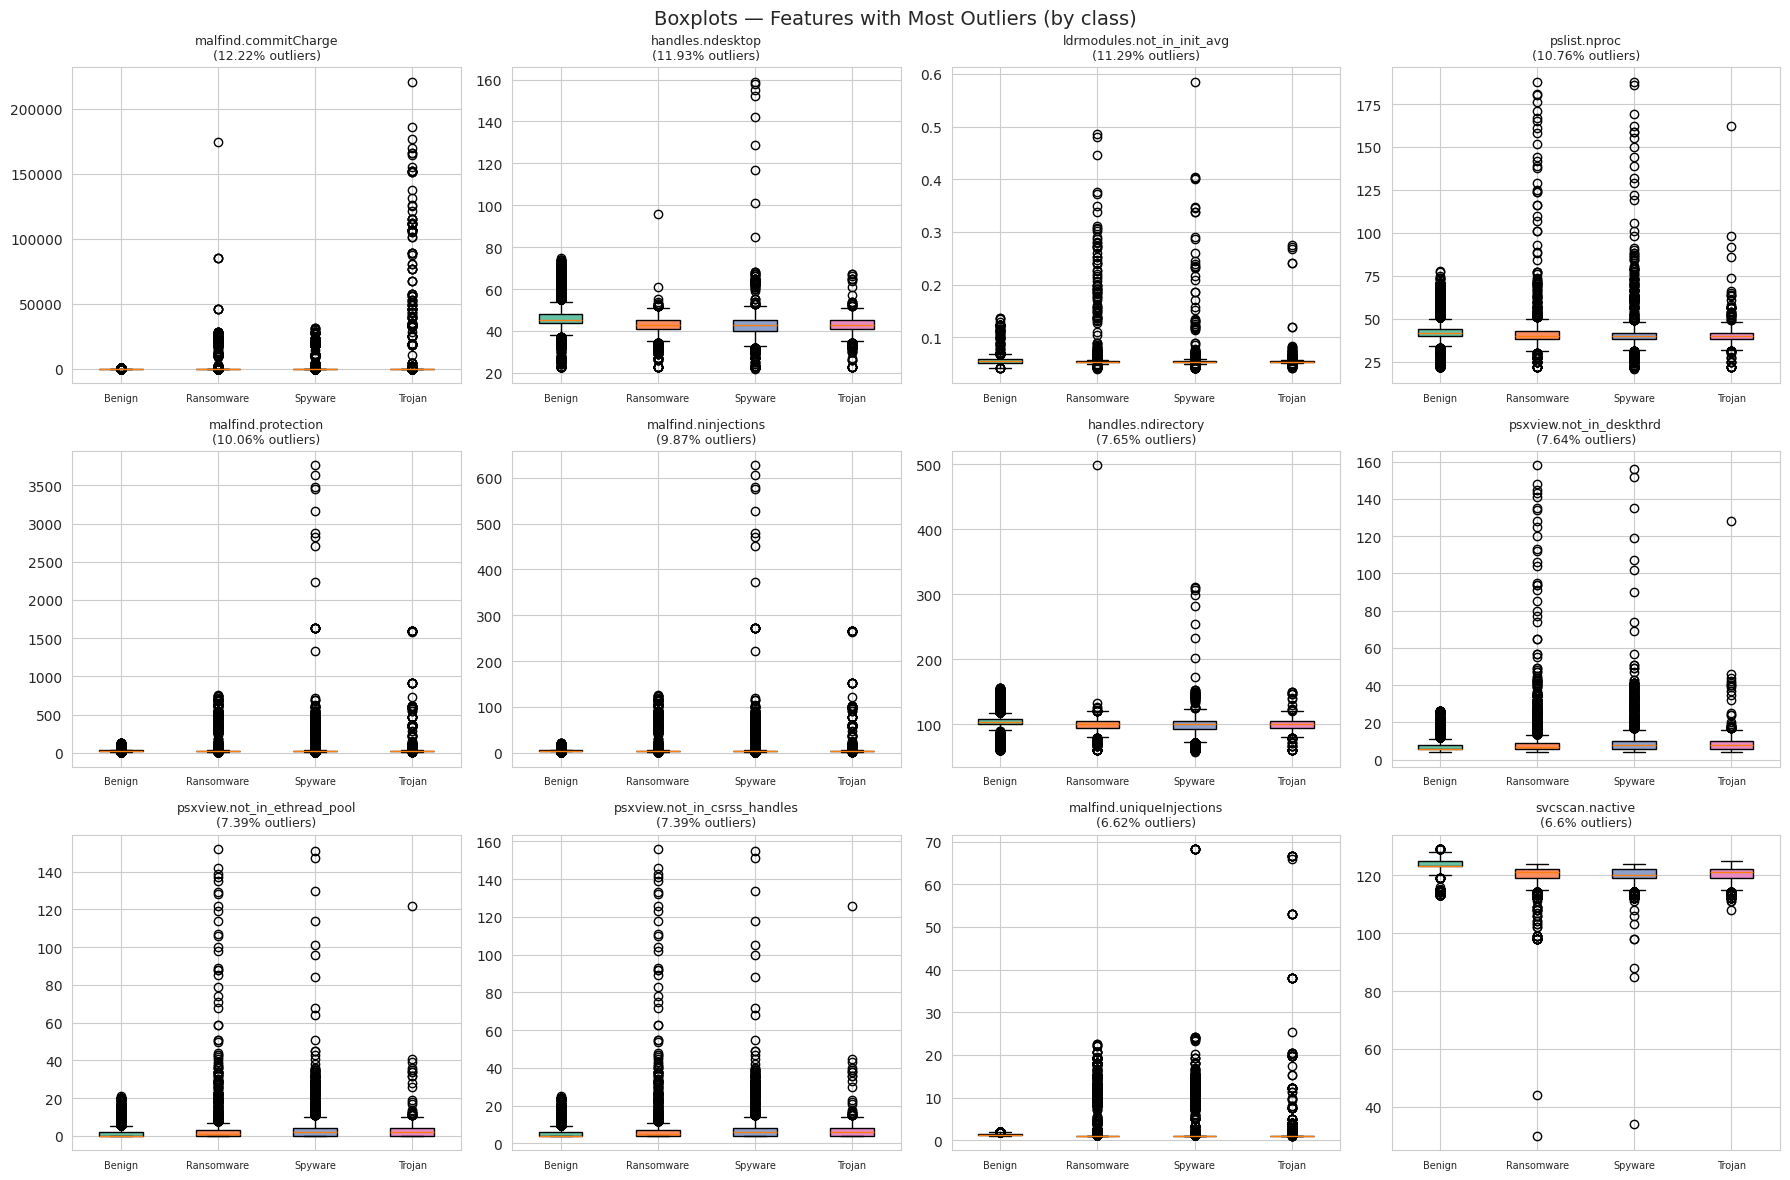

In [19]:
# Boxplots for the 12 features with the highest outlier percentage
top_outlier_feats = outlier_report.head(12).index.tolist()

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for ax, col in zip(axes.ravel(), top_outlier_feats):
    data = [X_train.loc[y_train == cat, col] for cat in sorted(y_train.unique())]
    bp = ax.boxplot(data, labels=sorted(y_train.unique()), patch_artist=True)
    colors = ["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3"]
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
    ax.set_title(f"{col}\n({outlier_pct[col]}% outliers)", fontsize=9)
    ax.tick_params(axis="x", labelsize=7)

plt.suptitle("Boxplots — Features with Most Outliers (by class)", fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
# Compare outlier rates between Benign and Malware classes
benign_mask = y_train == "Benign"
malware_mask = ~benign_mask

outlier_matrix = (X_train < lower) | (X_train > upper)
benign_outlier_rate = outlier_matrix[benign_mask].mean()
malware_outlier_rate = outlier_matrix[malware_mask].mean()

comparison = pd.DataFrame({
    "Benign outlier %": (benign_outlier_rate * 100).round(2),
    "Malware outlier %": (malware_outlier_rate * 100).round(2),
    "Diff (Malware - Benign)": ((malware_outlier_rate - benign_outlier_rate) * 100).round(2)
}).sort_values("Diff (Malware - Benign)", ascending=False)

print("Features where malware has more outliers than benign (top 10):")
print(comparison.head(10).to_string())
print("\nFeatures where benign has more outliers (top 10):")
print(comparison.tail(10).to_string())

Features where malware has more outliers than benign (top 10):
                          Benign outlier %  Malware outlier %  Diff (Malware - Benign)
malfind.uniqueInjections              2.33              11.01                     8.68
malfind.commitCharge                  8.62              15.91                     7.29
modules.nmodules                      1.50               6.16                     4.67
malfind.ninjections                   7.99              11.81                     3.82
malfind.protection                    8.35              11.81                     3.45
svcscan.nactive                       5.08               8.17                     3.10
callbacks.ncallbacks                  0.00               1.81                     1.81
handles.nsemaphore                    1.16               2.81                     1.65
svcscan.kernel_drivers                0.00               1.51                     1.51
svcscan.nservices                     0.00               1.50      

### 4d. Imputation Decision

Based on the audit above:
- **Missing values**: If any nulls were found, apply median imputation (robust to the heavy-tailed distributions we observed). If none, no imputation needed.
- **Outliers**: We retain outliers since the Benign vs Malware outlier comparison shows that extreme values are **class-discriminative** — removing them would discard the malware signal. The `RobustScaler` used later is resistant to these outliers.

In [21]:
# Impute missing values if any exist (median strategy — robust to skew)
from sklearn.impute import SimpleImputer

total_nulls = X_train.isnull().sum().sum()
if total_nulls > 0:
    print(f"Found {total_nulls} null values — applying median imputation...")
    imputer = SimpleImputer(strategy="median")
    X_train = pd.DataFrame(
        imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index
    )
    X_test = pd.DataFrame(
        imputer.transform(X_test), columns=X_test.columns, index=X_test.index
    )
    print(f"After imputation — nulls in train: {X_train.isnull().sum().sum()}")
    print(f"After imputation — nulls in test:  {X_test.isnull().sum().sum()}")
else:
    print("No missing values — imputation not needed.")

# Final data quality summary
print(f"\nCleaned training set: {X_train.shape[0]} rows, {X_train.shape[1]} features")
print(f"Cleaned test set:    {X_test.shape[0]} rows, {X_test.shape[1]} features")
print(f"NaN: {X_train.isnull().sum().sum()} | Inf: {np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum()}")

No missing values — imputation not needed.

Cleaned training set: 46163 rows, 55 features
Cleaned test set:    11634 rows, 55 features
NaN: 0 | Inf: 0


## Step 5: Impossible Value Check (Security-Aware)
In malware analysis, extreme values often **are** the signal (e.g., 5000 injected threads).  
We only remove rows with **mathematically impossible** values (negative counts) or clearly corrupted data — not statistical outliers.

In [22]:
# Check for impossible values: negative counts in columns that should be non-negative
count_cols = [c for c in X_train.columns if not c.endswith("_avg") and "avg" not in c]
negative_mask = (X_train[count_cols] < 0).any(axis=1)
print(f"Rows with negative count values: {negative_mask.sum()}")

# Check for NaN/Inf
print(f"NaN values in train: {X_train.isna().sum().sum()}")
print(f"Inf values in train: {np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum()}")

# Summary stats to eyeball suspicious ranges
print("\nDescriptive statistics (training set):")
X_train.describe().T[["min", "max", "mean", "std"]].round(3)

Rows with negative count values: 0
NaN values in train: 0
Inf values in train: 0

Descriptive statistics (training set):


,min,max,mean,std
pslist.nproc,21.000,188.000,41.404,5.771
pslist.nppid,8.000,72.000,14.702,2.696
pslist.avg_threads,1.995,16.818,11.361,1.585
pslist.nprocs64bit,0.000,0.000,0.000,0.000
pslist.avg_handlers,44.101,24845.951,248.311,123.839
dlllist.ndlls,670.000,3443.000,1814.586,330.426
dlllist.avg_dlls_per_proc,8.633,53.171,43.787,5.734
handles.nhandles,3514.000,1047310.000,10294.426,5358.105
handles.avg_handles_per_proc,71.139,33784.194,250.407,162.874
handles.nport,0.000,0.000,0.000,0.000
